In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [2]:
import polars as pl

from api.config.segmentation_config import SegmentationConfig
from api.config.data_quality_config import DataQualityConfig
from api.config.output_config import OutputConfig
from moviasai.profiling.segmentation_pipeline import VehicleSegmentationPipeline
from moviasai.data.utils import load_raw_data

In [3]:
cfg = SegmentationConfig.from_yaml('../config/segmentation_config.yaml')
output_cfg = OutputConfig.from_yaml('../config/output_config.yaml')
dq_cfg = DataQualityConfig.from_yaml('../config/data_quality_config.yaml')
cfg, output_cfg, dq_cfg

(SegmentationConfig(features=FeaturesConfig(type=['razao_km_h', 'proporcao_km', 'corr_km_h'], km=MetricFeaturesConfig(seg=['gap_medio', 'cv_gaps', 'taxa_dias_ativos', 'p75', 'iqr']), h=MetricFeaturesConfig(seg=['gap_medio', 'cv_gaps', 'taxa_dias_ativos', 'p75', 'iqr'])), stage1=Stage1Config(clustering=ClusteringConfig(k=2, k_range=(2, 10)), classification=Stage1ClassificationConfig(test_size=0.3, percentile_clean=0.1), uncertainty=UncertaintyConfig(low_pct=0.05, high_pct=0.95)), stage2=Stage2Config(clustering=ClusteringConfig(k=None, k_range=(2, 8)), classification=Stage2ClassificationConfig(test_size=0.3)), report=ReportConfig(enabled=True)),
 OutputConfig(data=DataConfig(train_dataset='C:\\Users\\f0pi\\git\\apimovias\\data\\train_data', profiles='C:\\Users\\f0pi\\git\\apimovias\\data\\profiles', cache='C:\\Users\\f0pi\\git\\apimovias\\data\\.dataset_cache'), logs=LogsConfig(segmentation='C:\\Users\\f0pi\\git\\apimovias\\logs\\segmentation', training='C:\\Users\\f0pi\\git\\apimovias\\

In [4]:
DATA_PATH = '../../datasets/full/telemetria_movias2025_features.csv'
df_daily = load_raw_data(DATA_PATH)
df_daily

veiculo_id,data,km_dia_clean,h_dia_clean
i64,date,f64,f64
1,2025-01-01,0.0,0.0
1,2025-01-02,0.0,0.0
1,2025-01-03,0.0,0.0
1,2025-01-04,0.0,0.0
1,2025-01-05,0.0,0.0
…,…,…,…
9999,2025-10-06,0.0,0.0
9999,2025-10-07,0.0,0.0
9999,2025-10-08,0.0,0.0


PIPELINE INICIALIZADO
Registros: 5,707,827
Veículos: 20169
Output: C:\Users\f0pi\git\apimovias\logs\segmentation

Features selecionadas:
  • Tipo: 3
  • Segmentação KM: 5
  • Segmentação H: 5


PIPELINE COMPLETO
Timestamp: 2026-04-26 15:41:17
Output: C:\Users\f0pi\git\apimovias\logs\segmentation

GERANDO FEATURES
Features totais: 13
Veículos: 20169

🗑️  Séries vazias (km=0 e h=0): 9,262 veículos removidos
Dataset carregado: 3,086,681 registros
Veiculos: 10907
Target: km

Dataset carregado: 3,086,681 registros
Veiculos: 10907
Target: h

FILTRANDO DATASET
Target: km
Min weeks: 12
Max gap: 4


🚀 Iniciando construção de janelas...
   Target: km
   Window size: 7 dias (1 semanas)
   Stride: 7 dias
   Max gap: 4

📍 Etapa 1: Identificando períodos contínuos...
   ✓ 24,210 períodos identificados
   ✓ 10,012 veículos únicos

📍 Etapa 2: Gerando segmentos de janelas (vetorizado)...

🔍 GERAÇÃO DE JANELAS (VETORIZADA)
   🔄 Pré-computando semanas ativas...
      ✓ 286,248 semanas ativas para 10,907 

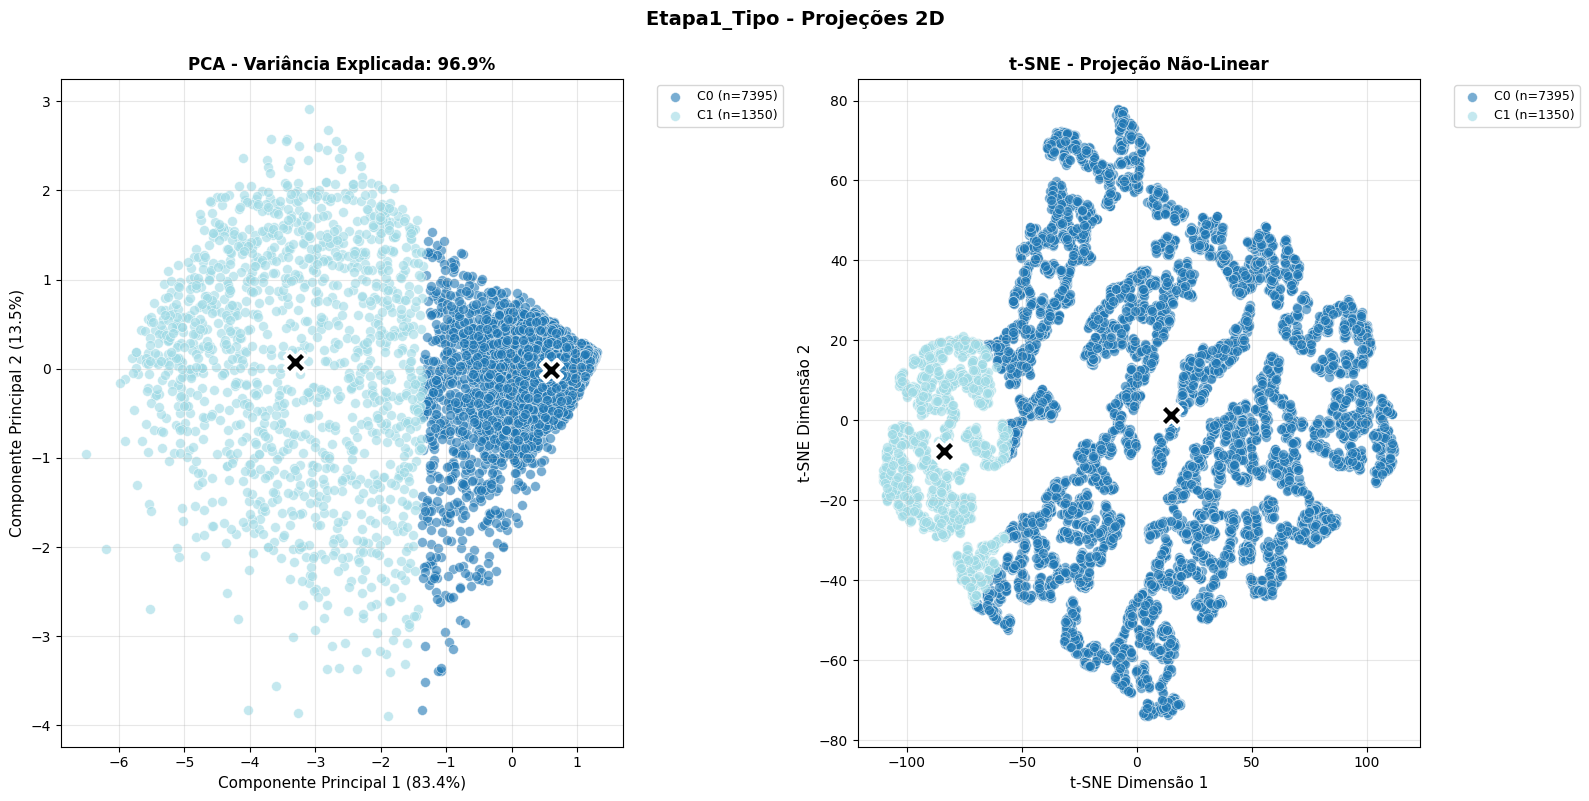

✓ Projeções (PCA + t-SNE): Etapa1_Tipo_projections.png

✓ Clusters salvos: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage1\clusters_metrica.csv

Limiares sugeridos:
  km_prop_min: 0.925
  h_prop_max: 0.822
  km_ratio_min: 2.596
  h_ratio_max: 1.726
  corr_min: -0.170

Filtragem de amostras ruidosas:
Features disponíveis:
  • proporcao_km: ✓
  • razao_km_h:   ✓
  • corr_km_h:    ✓

Critérios aplicados:
  KM: prop_km < 0.9254516791985062 OR razao < 2.596308200466805 OR corr < -0.16953361788055615
  H:  prop_km > 0.8219306093866657 OR razao > 1.7255823699414983 OR corr < -0.16953361788055615

Resultados:
  Total inicial:          8,745
  KM inconsistente:         746
  H inconsistente:          243
  Total removido:           989 ( 11.3%)
  Total mantido (clean):  7,756 ( 88.7%)

Removidos por tipo:
  KM          :    746 ( 75.4% dos removidos)
  H           :    243 ( 24.6% dos removidos)



TREINAMENTO - stage1_type
Amostras: 7756, Features: 3, Classes: 2

Treino: 5429 |

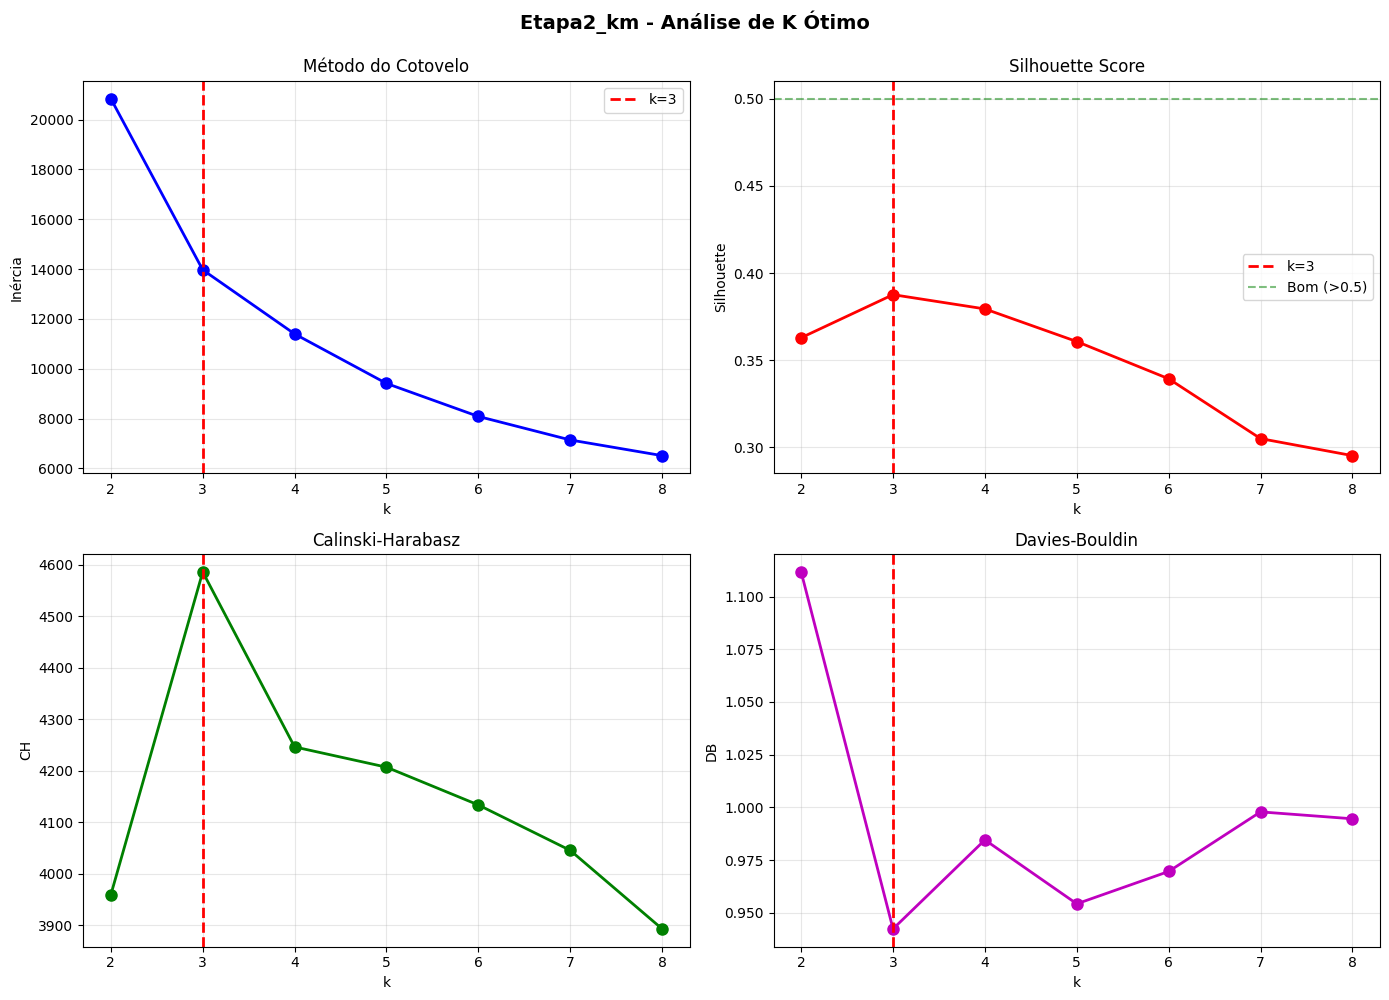

✓ Gráfico: Etapa2_km_k_analysis.png

Métricas:
  Silhouette: 0.3876
  Calinski-Harabasz: 4585.62
  Davies-Bouldin: 0.9424

Distribuição:
  Cluster 0:  3092 ( 46.5%)
  Cluster 1:  2338 ( 35.2%)
  Cluster 2:  1219 ( 18.3%)

Calculando PCA...
  Variância: 89.95%
Calculando t-SNE...
  ✓ Concluído

✓ Modelo: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_km_model.pkl
✓ Métricas: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_km_metrics.json
✓ Estatísticas: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_km_cluster_stats.csv



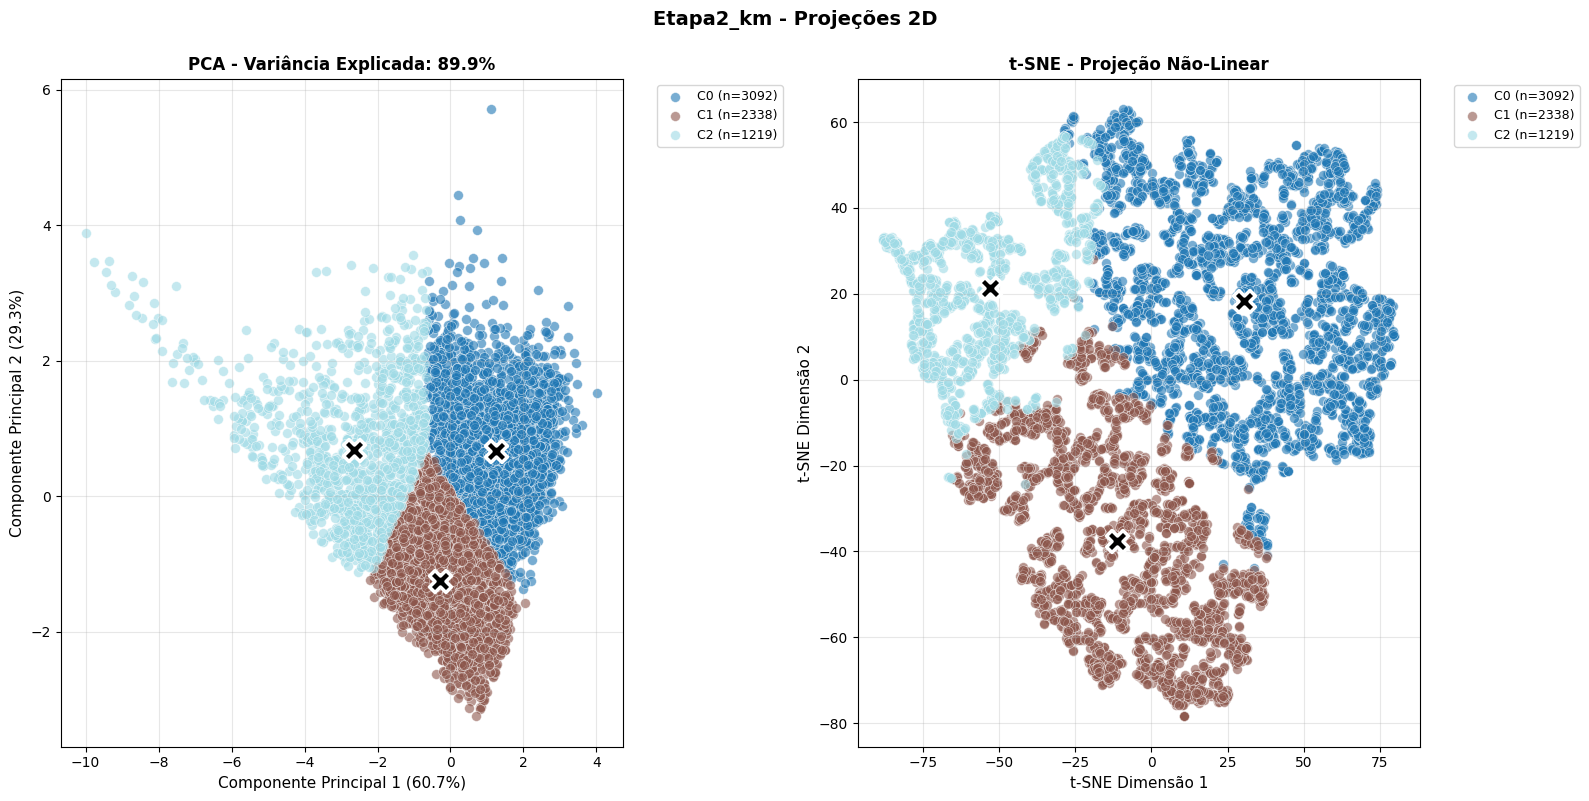

✓ Projeções (PCA + t-SNE): Etapa2_km_projections.png

H: 1107 veículos

CLUSTERIZAÇÃO - Etapa2_h
Amostras: 1107
Features: 5


BUSCA DE K ÓTIMO - Etapa2_h

  k= 2: sil=0.3754, CH=  769.01, DB=1.0051
  k= 3: sil=0.3597, CH=  766.07, DB=1.0020
  k= 4: sil=0.3114, CH=  729.95, DB=1.0164
  k= 5: sil=0.3341, CH=  737.44, DB=0.9580
  k= 6: sil=0.3327, CH=  700.77, DB=0.9484
  k= 7: sil=0.3422, CH=  702.82, DB=0.9578
  k= 8: sil=0.3178, CH=  689.62, DB=0.9784

✓ K ótimo: 2



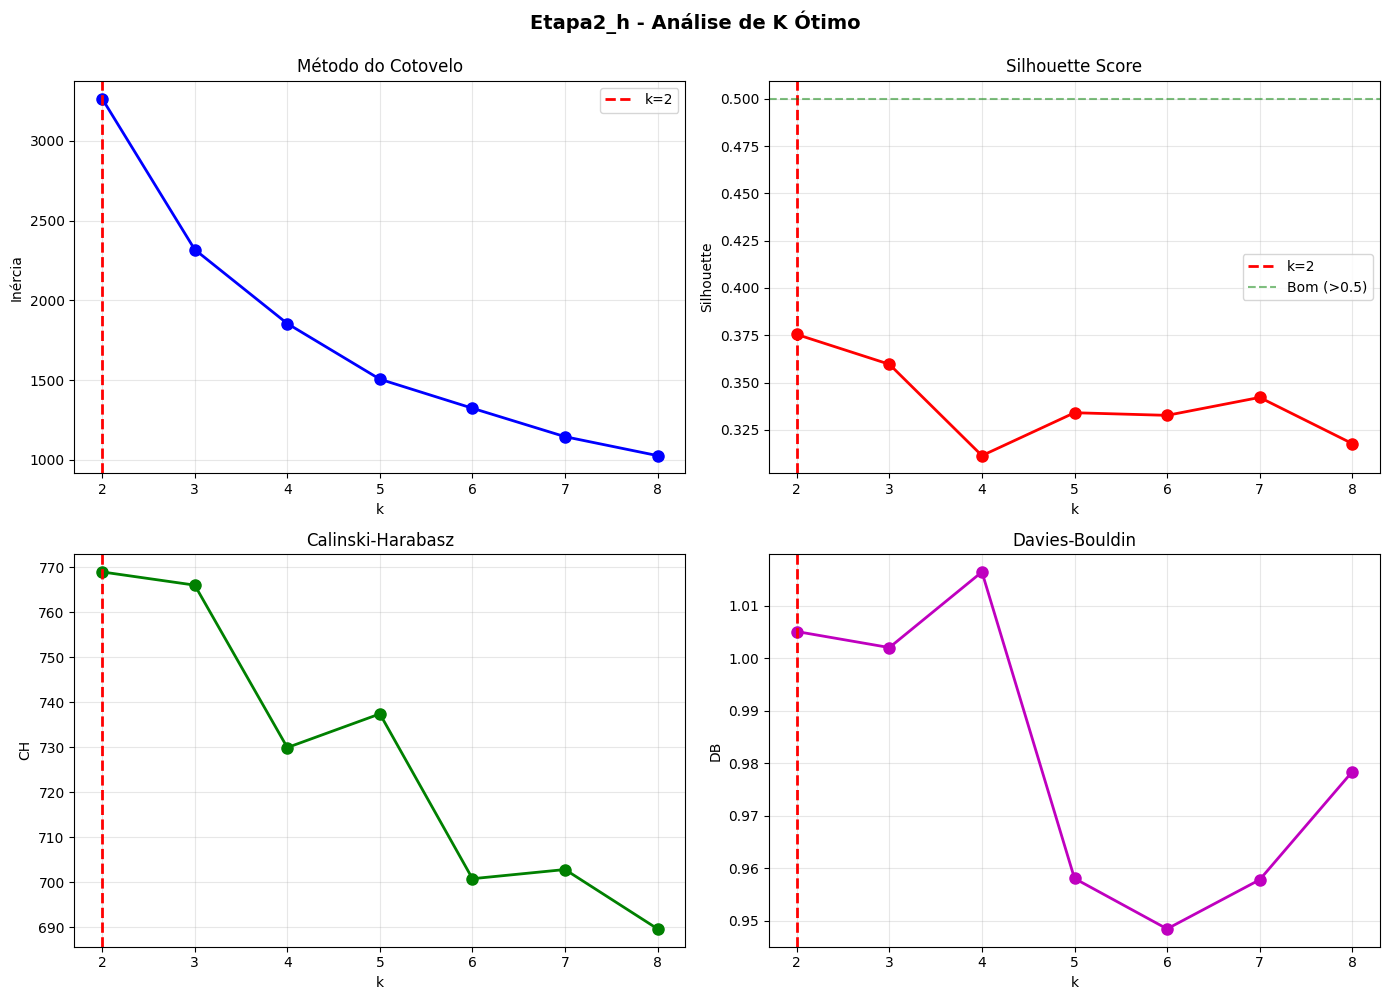

✓ Gráfico: Etapa2_h_k_analysis.png

Métricas:
  Silhouette: 0.3754
  Calinski-Harabasz: 769.01
  Davies-Bouldin: 1.0051

Distribuição:
  Cluster 0:   463 ( 41.8%)
  Cluster 1:   644 ( 58.2%)

Calculando PCA...
  Variância: 91.22%
Calculando t-SNE...
  ✓ Concluído

✓ Modelo: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_h_model.pkl
✓ Métricas: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_h_metrics.json
✓ Estatísticas: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\Etapa2_h_cluster_stats.csv



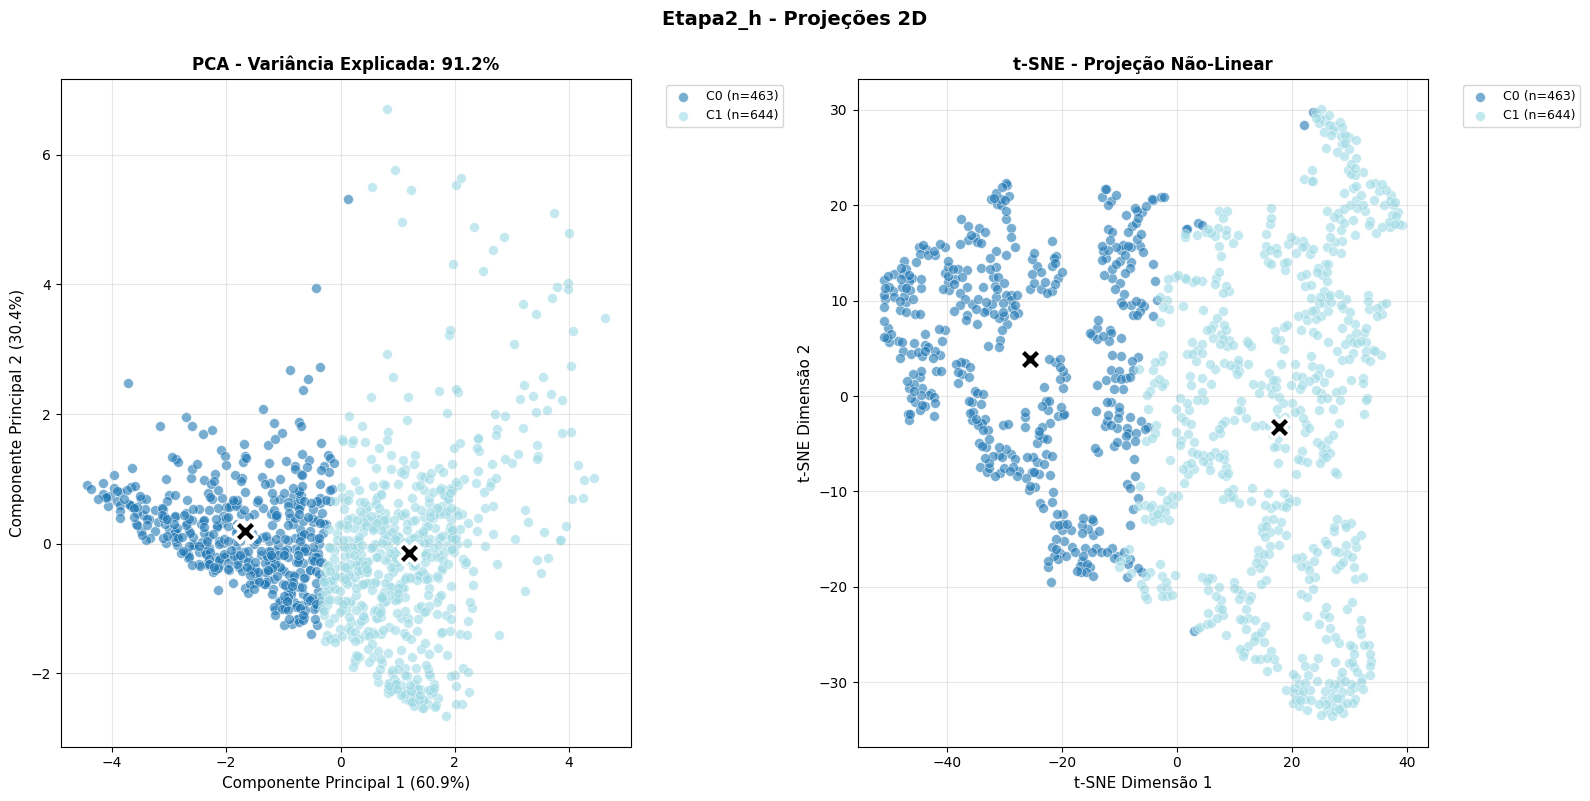

✓ Projeções (PCA + t-SNE): Etapa2_h_projections.png

✓ Clusters salvos: C:\Users\f0pi\git\apimovias\logs\segmentation\clustering\stage2\clusters_segmento.csv


CLASSIFICAÇÃO: KM
Veículos: 6649
Clusters: 3


TREINAMENTO - stage2_km
Amostras: 6649, Features: 5, Classes: 3

Treino: 4654 | Teste: 1995

LogisticRegression: Acc=0.9975, F1=0.9975, Acc_train=0.9948, F1_train=0.9949, CV=0.9946±0.0013
RandomForest: Acc=0.9890, F1=0.9890, Acc_train=1.0000, F1_train=1.0000, CV=0.9836±0.0038

✓ Melhor: LogisticRegression (F1=0.9975)

✓ Modelos PKL salvos: C:\Users\f0pi\git\apimovias\models\classification\stage2
✓ ONNX salvo: C:\Users\f0pi\git\apimovias\models\classification\stage2\stage2_km_BEST.onnx
  • Scaler (JSON): C:\Users\f0pi\git\apimovias\models\classification\stage2\stage2_km_BEST_scaler.json
  • Metadata: C:\Users\f0pi\git\apimovias\models\classification\stage2\stage2_km_BEST_metadata.json


CLASSIFICAÇÃO: H
Veículos: 1107
Clusters: 2


TREINAMENTO - stage2_h
Amostras: 1107, Features: 5, 

In [5]:
pipeline = VehicleSegmentationPipeline.from_config(df_daily, cfg, output_cfg, dq_cfg)
results = pipeline.run()